In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("sales_data_with_discounts.csv")

In [3]:
df

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501200
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102960,89323.897040
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910160,102042.089800
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925300
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770
...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,15-04-2021,Thursday,L06,C,2,Lifestyle,Jeera,M-Casuals,1300,2600,15.475687,402.367873,2197.632127
446,15-04-2021,Thursday,L07,C,6,Lifestyle,Viva,W-Western,2600,15600,17.057027,2660.896242,12939.103760
447,15-04-2021,Thursday,L08,C,2,Lifestyle,Viva,W-Lounge,1600,3200,18.965550,606.897606,2593.102394
448,15-04-2021,Thursday,L09,C,3,Lifestyle,Jeera,M-Formals,1900,5700,16.793014,957.201826,4742.798174


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB


In [52]:
numerical_data = df.select_dtypes(include=['int64','float64']).columns

numerical_data

Index(['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)',
       'Discount Amount', 'Net Sales Value'],
      dtype='object')

#### mean, median std

In [61]:
stats = df[['Volume', 'Avg Price', 'Total Sales Value',
            'Discount Rate (%)', 'Discount Amount',
            'Net Sales Value']].agg(['mean','median','std', 'count', 'min', 'max'])

stats

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
mean,5.066667,10453.433333,33812.835556,15.155242,3346.499424,30466.336131
median,4.000000,1450.000000,5700.000000,16.577766,988.933733,4677.788059
std,4.231602,18079.904840,50535.074173,4.220602,4509.902963,46358.656624
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
min,1.000000,290.000000,400.000000,5.007822,69.177942,326.974801
max,31.000000,60100.000000,196400.000000,19.992407,25738.022190,179507.479000


#### mode

In [54]:
mode = df[['Volume', 'Avg Price', 'Total Sales Value',
           'Discount Rate (%)', 'Discount Amount',
           'Net Sales Value']].mode().iloc[0]

mode

Volume                   3.000000
Avg Price              400.000000
Total Sales Value    24300.000000
Discount Rate (%)        5.007822
Discount Amount         69.177942
Net Sales Value        326.974801
Name: 0, dtype: float64

In [55]:
stats.loc['mode'] = mode

In [56]:
stats

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
mean,5.066667,10453.433333,33812.835556,15.155242,3346.499424,30466.336131
median,4.000000,1450.000000,5700.000000,16.577766,988.933733,4677.788059
std,4.231602,18079.904840,50535.074173,4.220602,4509.902963,46358.656624
mode,3.000000,400.000000,24300.000000,5.007822,69.177942,326.974801


### Visualization - Histogram

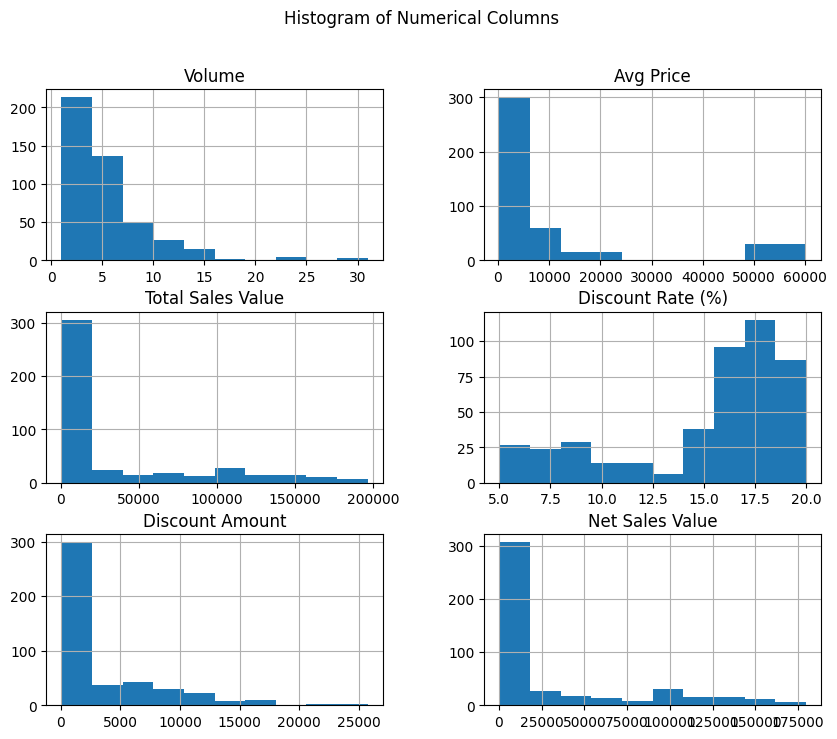

In [70]:
import matplotlib.pyplot as plt

numerical_data.hist(figsize=(10, 8), layout=(3, 2))

plt.suptitle("Histogram of Numerical Columns")

plt.show()

###### Data shows right skewness in some variables like sales values
###### Most values are concentrated at lower range
###### Few high values create long tail
###### This indicates presence of high-value outliers

### Boxplot

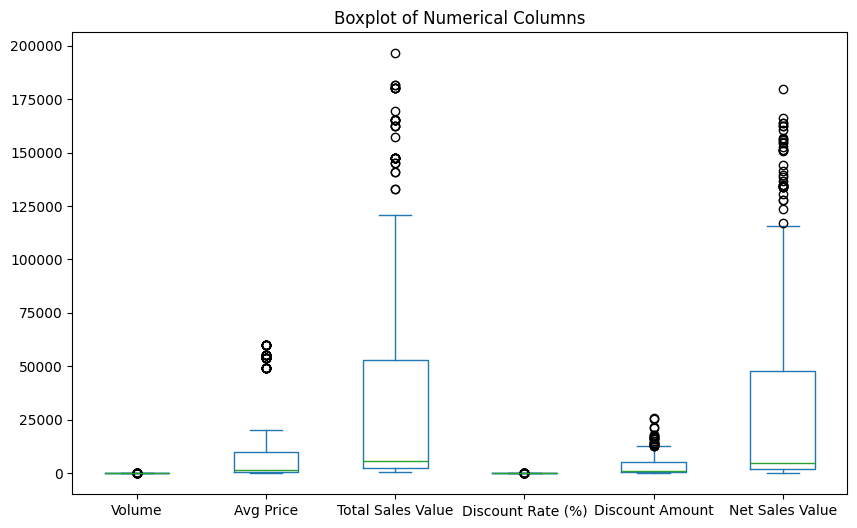

In [71]:
import matplotlib.pyplot as plt

numerical_data.plot(kind='box', figsize=(10, 6))

plt.title("Boxplot of Numerical Columns")
plt.show()

###### Boxplot shows presence of outliers in some columns
###### Few extreme values are observed in sales/discount related variables
###### Most data lies within interquartile range

#### Bar Chart

In [73]:
categorical_data = df.select_dtypes(include=['object'])

categorical_data.columns

Index(['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object')

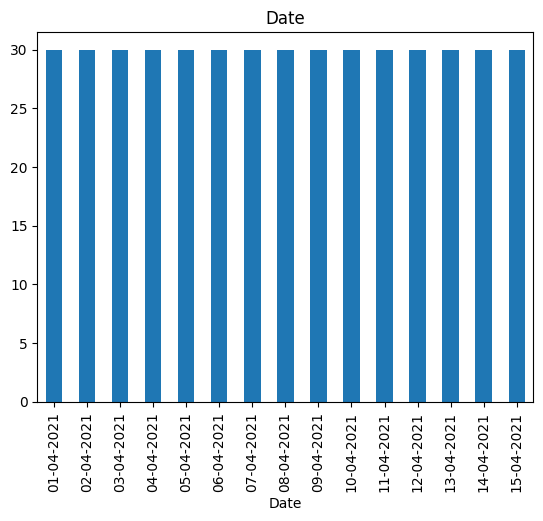

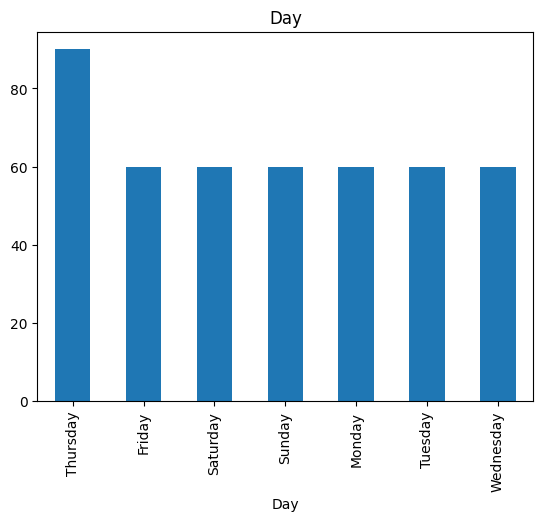

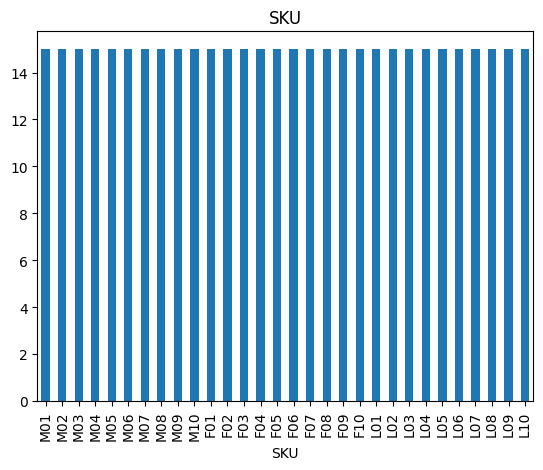

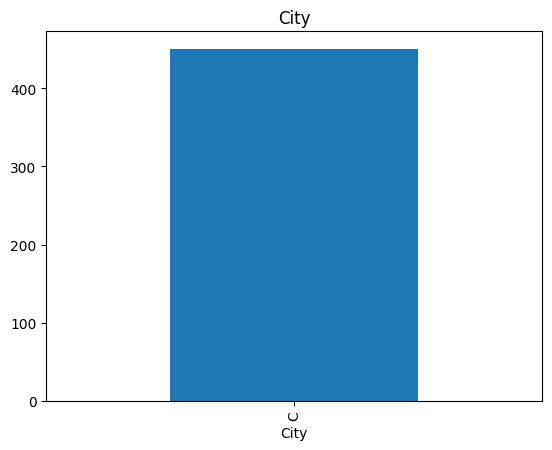

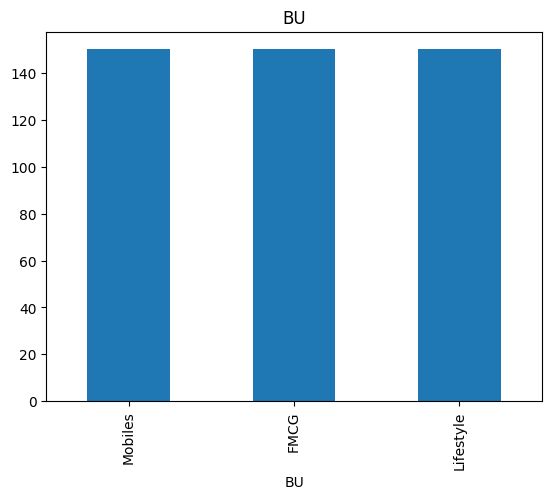

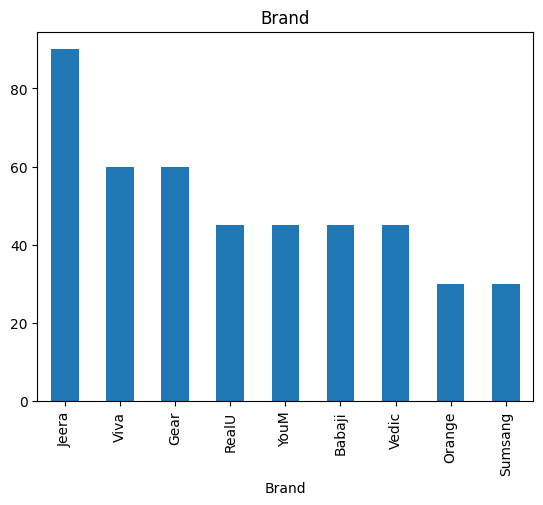

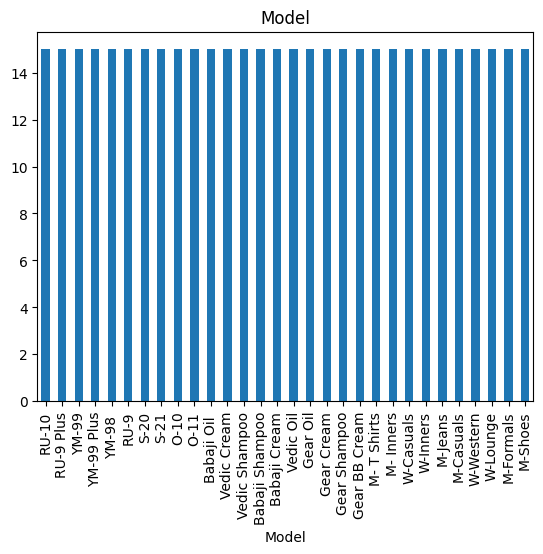

In [75]:
import matplotlib.pyplot as plt

for col in categorical_data.columns:
    categorical_data[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show()

###### Bar plot is used to visualize the frequency of categorical variables.
###### It shows how many times each category appears in the dataset.
###### From the plot, we can identify the most and least frequent categories.
###### This helps in understanding data distribution and imbalance in categories.

### Standardization (Z-score Scaling)

In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(numerical_data)

In [78]:
import pandas as pd

scaled_df = pd.DataFrame(scaled_data, columns=numerical_data.columns)

scaled_df.head()

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,2.350029,0.091173,2.925721,-0.830289,3.952816,2.804756
1,1.167129,-0.019570,1.330995,-0.852661,1.849014,1.271026
2,0.457388,0.312659,1.562775,-1.351631,1.622995,1.545675
3,0.220808,0.534146,1.719276,-1.949723,1.113807,1.765810
4,-0.488932,-0.130313,-0.188452,0.673739,0.227852,-0.227595


###### Data has been standardized using Z-score normalization.
###### All numerical features are now on a common scale with mean 0 and standard deviation 1.
###### This helps in improving model performance and avoids feature dominance.

#### Correlation Matrix

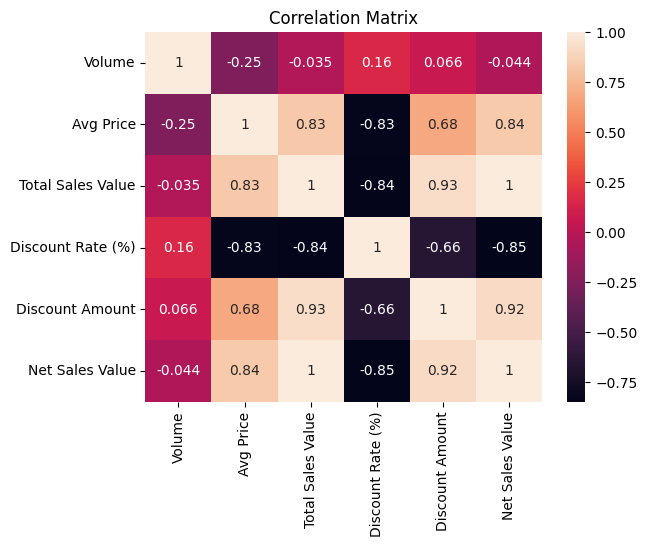

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = numerical_data.corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Matrix")
plt.show()

### Categorical → Dummy Variables

###### Machine learning models cannot work directly with categorical data.
###### Therefore, categorical variables are converted into dummy variables using one-hot encoding.
###### This creates binary columns (0/1) for each category.

In [80]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value,Date_02-04-2021,Date_03-04-2021,Date_04-04-2021,Date_05-04-2021,...,Model_Vedic Cream,Model_Vedic Oil,Model_Vedic Shampoo,Model_W-Casuals,Model_W-Inners,Model_W-Lounge,Model_W-Western,Model_YM-98,Model_YM-99,Model_YM-99 Plus
0,15,12100,181500,11.654820,21153.498820,160346.50120,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,10,10100,101000,11.560498,11676.102960,89323.89704,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,7,16100,112700,9.456886,10657.910160,102042.08980,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,6,20100,120600,6.935385,8364.074702,112235.92530,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,3,8100,24300,17.995663,4372.946230,19927.05377,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


# Conclusion:

###### The dataset was successfully analyzed using Exploratory Data Analysis (EDA). Descriptive statistics were used to
###### understand the central tendency and spread of numerical variables. Data visualization techniques such as histograms,
###### boxplots, and bar plots helped in understanding the distribution and identifying outliers as well as categorical patterns.
###### Correlation analysis showed relationships between numerical features. The data was then standardized to bring all variables
###### to a common scale and categorical variables were converted into dummy variables using one-hot encoding.